# ACF and PACF: Identifying Time Series Structure

## Overview

The ACF (autocorrelation function) and PACF (partial autocorrelation function) are the primary tools for identifying AR and MA orders in ARIMA models.

| Function | What it measures | Key use |
|---|---|---|
| **ACF** at lag k | Correlation between Y_t and Y_{t−k}, including indirect effects | Identifies MA(q) order: cuts off after lag q |
| **PACF** at lag k | Correlation between Y_t and Y_{t−k} after removing all intermediate lags | Identifies AR(p) order: cuts off after lag p |

**Pattern identification table:**

| Model | ACF | PACF |
|---|---|---|
| AR(p) | Decays exponentially | Cuts off after lag p |
| MA(q) | Cuts off after lag q | Decays exponentially |
| ARMA(p,q) | Tails off after q | Tails off after p |
| White noise | No significant lags | No significant lags |
| Non-stationary | Very slow decay | Large spike at lag 1 |

> **In practice:** Real series are usually ARMA, where both ACF and PACF tail off. Use the table as a starting point, then compare models by AIC/BIC using `auto.arima()`.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(forecast)   # ggAcf(), ggPacf(), checkresiduals()
library(patchwork)

set.seed(42)
n <- 300

# Helper: side-by-side ACF/PACF
plot_ap <- function(x, title, lag.max=30) {
  p1 <- forecast::ggAcf(x,  lag.max=lag.max) +
        labs(title=paste(title,"— ACF")) + theme_minimal(base_size=9)
  p2 <- forecast::ggPacf(x, lag.max=lag.max) +
        labs(title=paste(title,"— PACF")) + theme_minimal(base_size=9)
  p1 | p2
}

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'forecast' was built under R version 4.4.3"
Warning message:
"package 'patchwork' was built under R version

---

## Reference Patterns

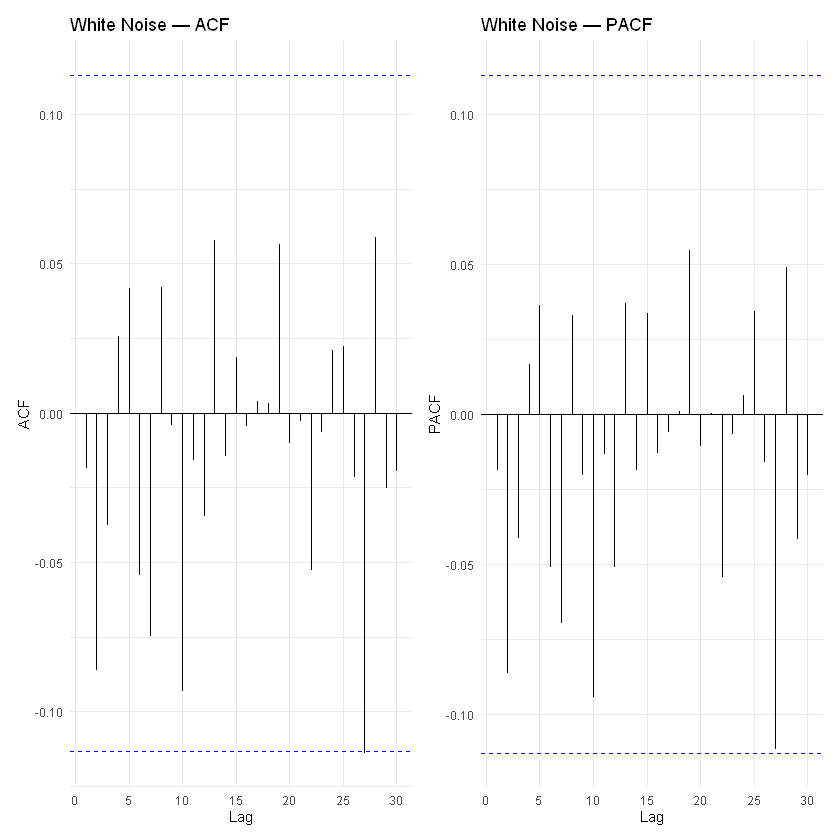

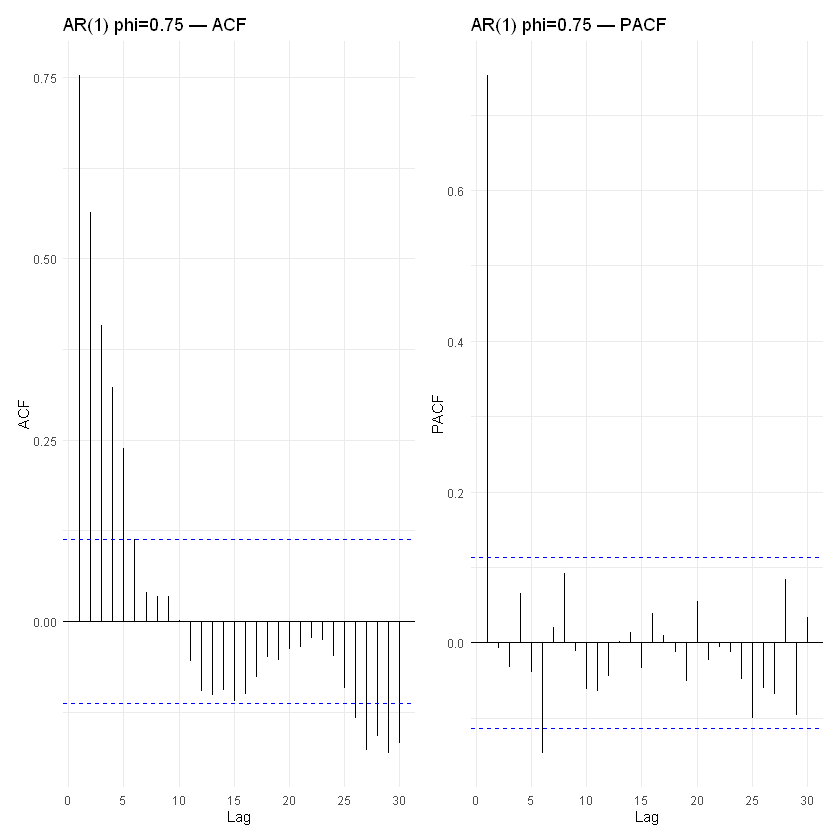

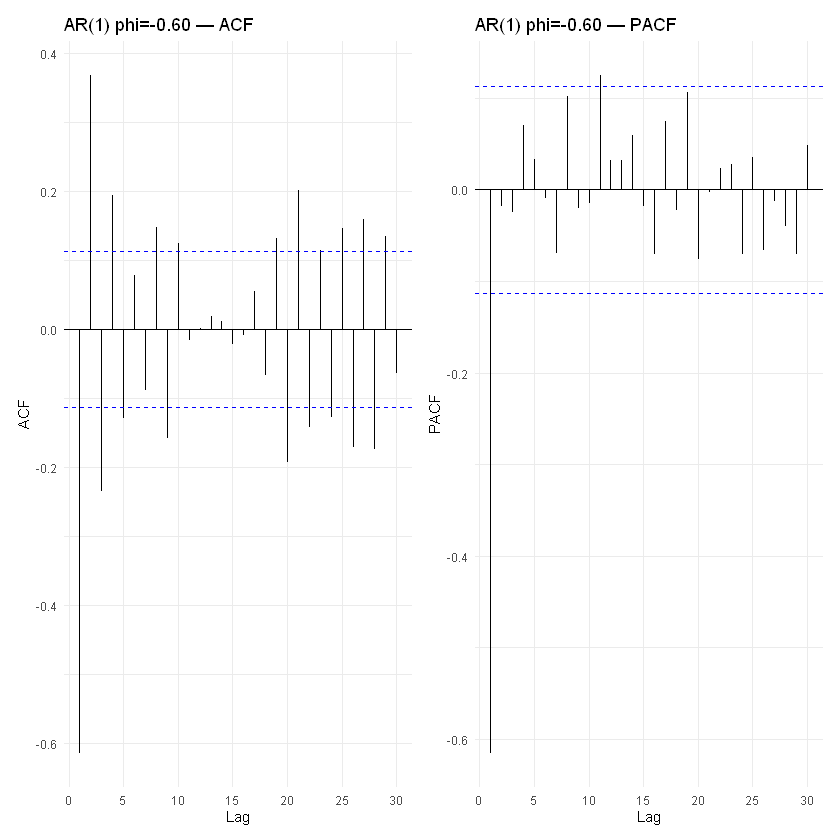

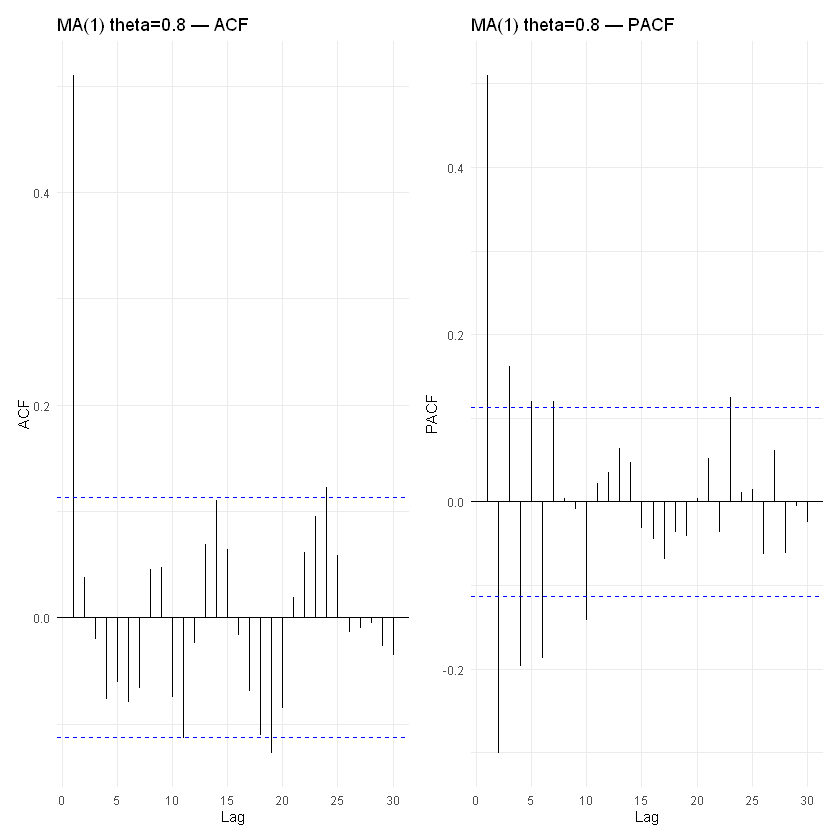

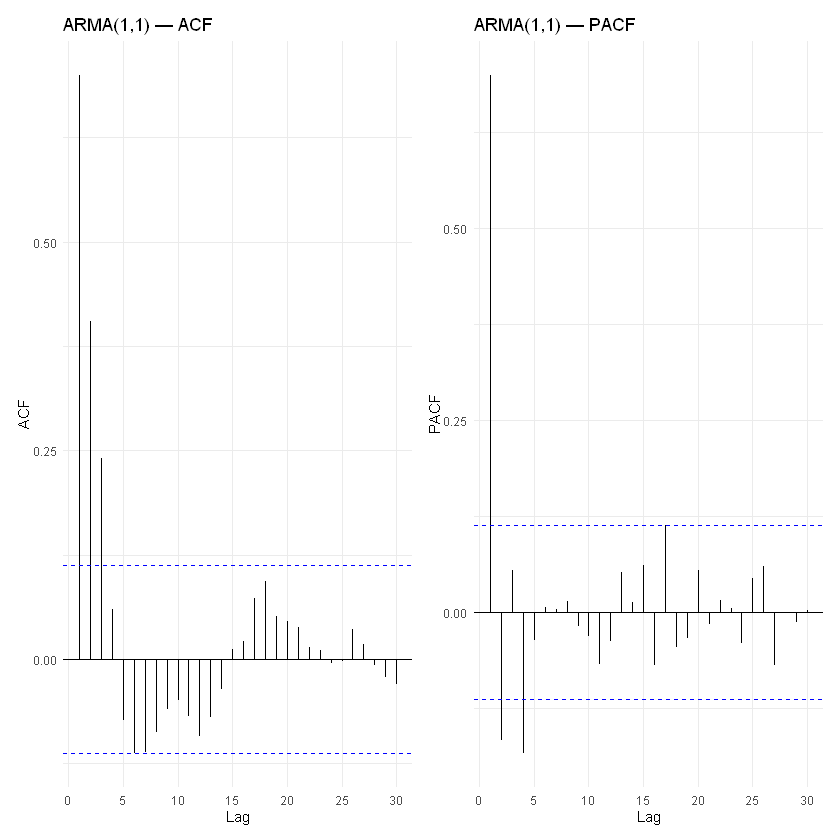

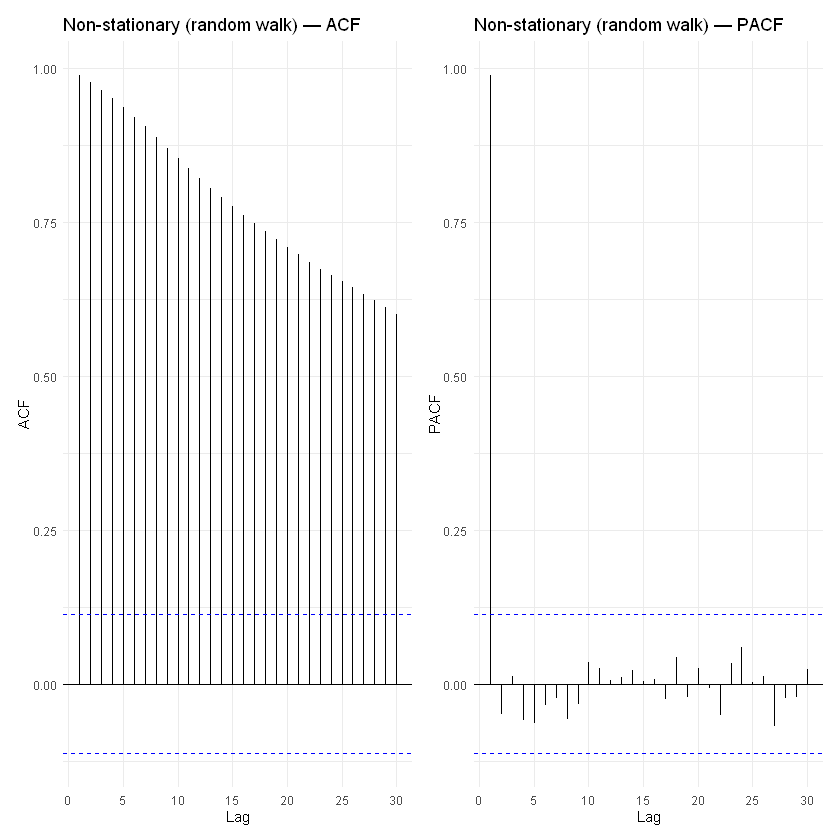

In [2]:
plot_ap(rnorm(n), "White Noise")
# No significant spikes in either

plot_ap(arima.sim(list(ar=0.75), n=n), "AR(1) phi=0.75")
# ACF: exponential decay; PACF: single spike at lag 1, then cuts off

plot_ap(arima.sim(list(ar=-0.6), n=n), "AR(1) phi=-0.60")
# ACF: alternating decay; PACF: single negative spike at lag 1

plot_ap(arima.sim(list(ma=0.8), n=n), "MA(1) theta=0.8")
# ACF: single spike at lag 1 then cuts off; PACF: exponential decay

plot_ap(arima.sim(list(ar=0.6, ma=0.4), n=n), "ARMA(1,1)")
# Both ACF and PACF tail off gradually — need AIC for selection

plot_ap(cumsum(rnorm(n)), "Non-stationary (random walk)")
# ACF very slow to decay; PACF large spike at lag 1 — always difference first

---

## Applied: Identifying Structure After Differencing

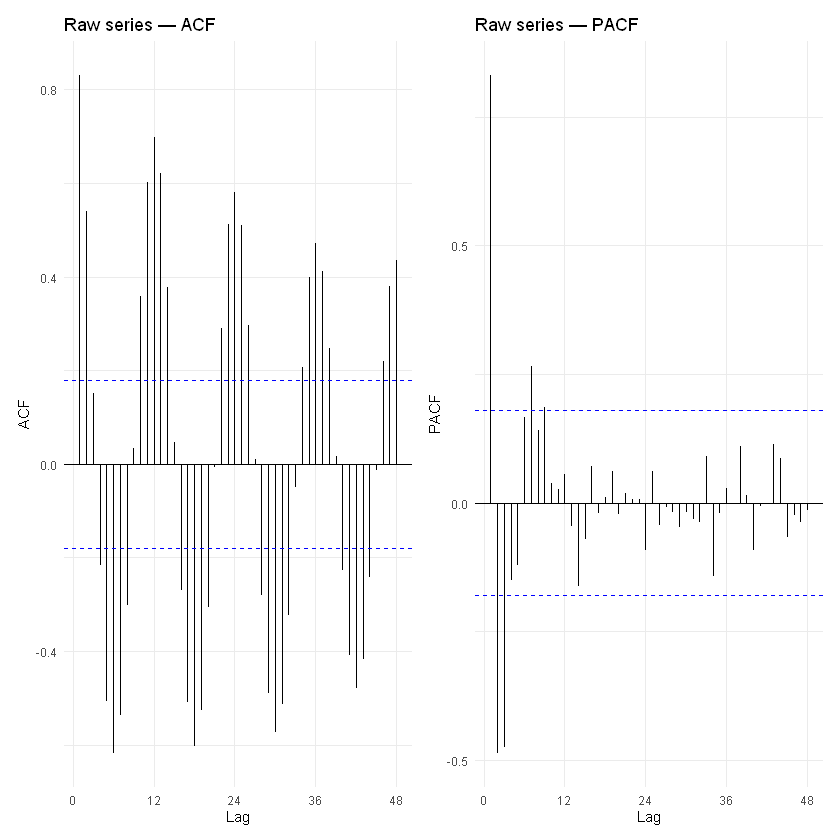

Suggested: SARIMA(1,1,1)(0,1,1)[12] — verify with auto.arima()


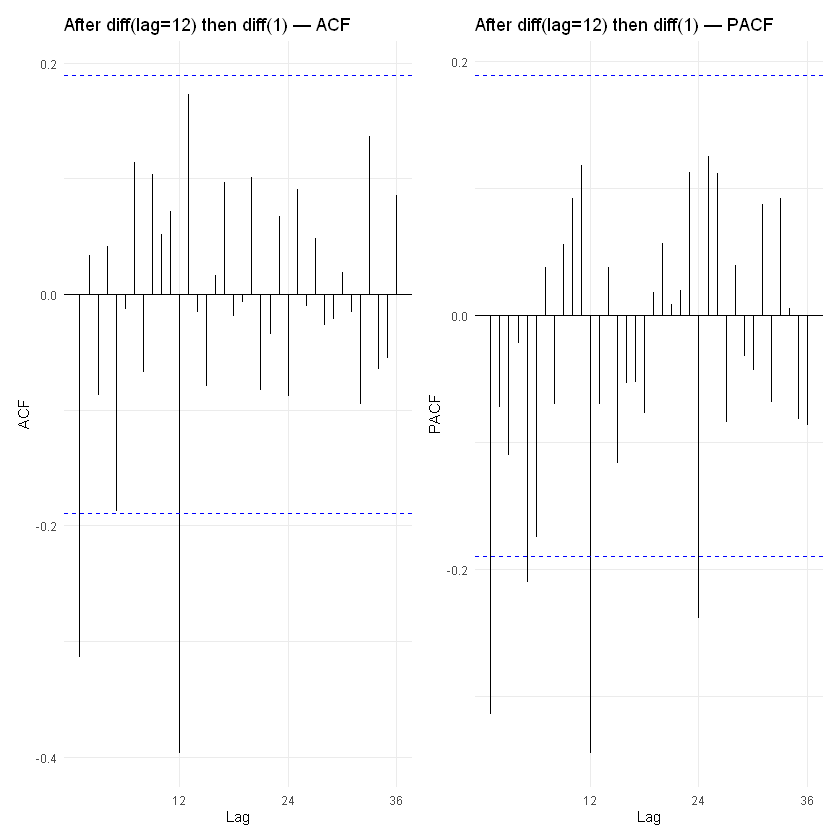

In [3]:
# Monthly ecological monitoring series
eco_ts <- ts(
  50 + 0.15 * 1:120 +
  18 * sin(2 * pi * 1:120 / 12) +
  arima.sim(list(ar=0.55), n=120, sd=5),
  start=c(2014,1), frequency=12
)

# Step 1: raw series — slow ACF decay + seasonal spikes at 12, 24, 36
plot_ap(eco_ts, "Raw series", lag.max=48)

# Step 2: after d=1 and D=1 (seasonal difference)
eco_diff <- diff(diff(eco_ts, lag=12), differences=1)
plot_ap(eco_diff, "After diff(lag=12) then diff(1)", lag.max=36)

# Reading the result:
# Non-seasonal: PACF spike at lag 1 → AR(1); ACF spike at lag 1 → MA(1) possible
# Seasonal: spike at lag 12 in ACF → seasonal MA (Q=1)
# Suggested starting model: SARIMA(1,1,1)(0,1,1)[12]
cat("Suggested: SARIMA(1,1,1)(0,1,1)[12] — verify with auto.arima()\n")

---

## Ljung-Box Test: Residual Autocorrelation After Fitting


	Ljung-Box test

data:  Residuals from ARIMA(1,0,0)(2,1,0)[12] with drift
Q* = 14.944, df = 21, p-value = 0.8257

Model df: 3.   Total lags used: 24

Ljung-Box Q(24)=14.944, p=0.8257


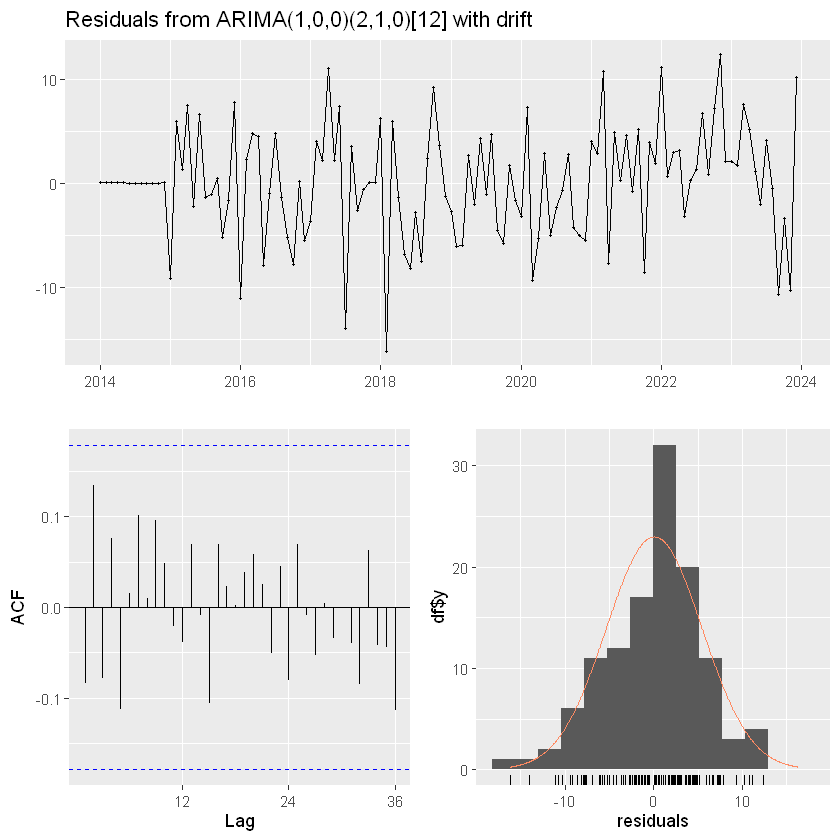

In [4]:
fit   <- forecast::auto.arima(eco_ts, seasonal=TRUE)
resid <- residuals(fit)

# checkresiduals: time plot + ACF + histogram + Ljung-Box
forecast::checkresiduals(fit)

# Manual Ljung-Box — subtract fitted AR+MA parameters from df
lb <- Box.test(resid, lag=24, type="Ljung-Box",
               fitdf=sum(fit$arma[1:4]))   # p+q+P+Q
cat(sprintf("Ljung-Box Q(%d)=%.3f, p=%.4f\n", 24, lb$statistic, lb$p.value))
# p > 0.05: residuals consistent with white noise → model adequate
# For seasonal models, always test at lag=2*m (24 for monthly data)

---

## Cross-Correlation Function (CCF): Lead-Lag Relationships

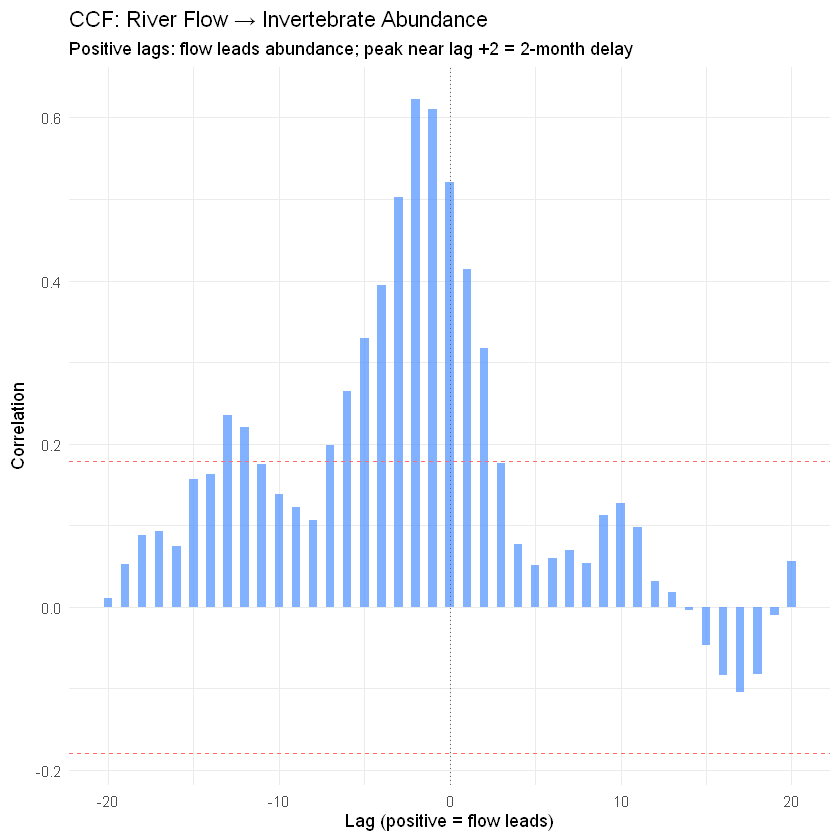

In [5]:
# River flow leads invertebrate abundance by ~2 months
flow      <- as.numeric(arima.sim(list(ar=0.8), n=120, sd=10) + 100)
abundance <- 0.4 * dplyr::lag(flow, 2) + rnorm(120, 0, 8)
abundance[1:2] <- mean(abundance, na.rm=TRUE)

ccf_res <- ccf(flow, abundance, lag.max=20, plot=FALSE)
ci <- qnorm(0.975) / sqrt(120)

tibble(lag=ccf_res$lag, acf=ccf_res$acf) %>%
  ggplot(aes(x=lag, y=acf)) +
  geom_col(fill="#4a8fff", alpha=0.7, width=0.5) +
  geom_hline(yintercept=c(-ci,ci), linetype="dashed", color="#ff6b6b") +
  geom_vline(xintercept=0, linetype="dotted", color="gray40") +
  labs(title="CCF: River Flow → Invertebrate Abundance",
       subtitle="Positive lags: flow leads abundance; peak near lag +2 = 2-month delay",
       x="Lag (positive = flow leads)", y="Correlation") +
  theme_minimal()

---

## Common Pitfalls

**1. Reading ACF/PACF before differencing**  
ACF and PACF of non-stationary series are not interpretable for ARIMA identification. Always confirm stationarity first and difference if needed.

**2. Over-interpreting isolated borderline spikes**  
At 5% significance, 1 in 20 spikes will cross the bounds by chance. Look for patterns — sustained decay or clean cutoffs — not isolated spikes.

**3. Applying the table mechanically to ARMA series**  
For ARMA(p,q), both ACF and PACF tail off. The identification table gives no clean answer. Use AIC/BIC via `auto.arima(stepwise=FALSE)` for model selection.

**4. Not checking residual ACF after fitting**  
A fitted model that leaves autocorrelation in residuals is misspecified. Always run `checkresiduals()` or `Box.test()` — and for seasonal models, test at lag = 2 × seasonal period.

**5. Confusing ACF lag units with time units**  
For monthly data, lag 12 in the ACF means 12 months = 1 year. Always interpret ACF lags in the time units of the data, not just as abstract integers.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*